In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("colorectal_cancer_prediction.csv")

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import FunctionTransformer

In [4]:
df.head()

,Patient_ID,Age,Gender,Race,Region,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,...,Insurance_Coverage,Time_to_Diagnosis,Treatment_Access,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Follow_Up_Adherence,Survival_Status,Recurrence,Time_to_Recurrence
0,1,71,Male,Other,Europe,Urban,Middle,Yes,No,III,...,Yes,Delayed,Good,Yes,No,No,Good,Survived,No,16
1,2,34,Female,Black,North America,Urban,Middle,No,No,I,...,No,Timely,Good,No,Yes,Yes,Poor,Deceased,No,28
2,3,80,Female,White,North America,Urban,Middle,No,No,III,...,Yes,Timely,Limited,No,Yes,Yes,Good,Survived,No,26
3,4,40,Male,Black,North America,Rural,Low,No,No,I,...,Yes,Delayed,Limited,Yes,No,Yes,Poor,Deceased,No,44
4,5,43,Female,White,Europe,Urban,High,Yes,No,III,...,No,Delayed,Good,Yes,No,Yes,Poor,Deceased,Yes,20


In [5]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Race', 'Region', 'Urban_or_Rural',
       'Socioeconomic_Status', 'Family_History', 'Previous_Cancer_History',
       'Stage_at_Diagnosis', 'Tumor_Aggressiveness', 'Colonoscopy_Access',
       'Screening_Regularity', 'Diet_Type', 'BMI', 'Physical_Activity_Level',
       'Smoking_Status', 'Alcohol_Consumption', 'Red_Meat_Consumption',
       'Fiber_Consumption', 'Insurance_Coverage', 'Time_to_Diagnosis',
       'Treatment_Access', 'Chemotherapy_Received', 'Radiotherapy_Received',
       'Surgery_Received', 'Follow_Up_Adherence', 'Survival_Status',
       'Recurrence', 'Time_to_Recurrence'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89945 entries, 0 to 89944
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               89945 non-null  int64  
 1   Age                      89945 non-null  int64  
 2   Gender                   89945 non-null  object 
 3   Race                     89945 non-null  object 
 4   Region                   89945 non-null  object 
 5   Urban_or_Rural           89945 non-null  object 
 6   Socioeconomic_Status     89945 non-null  object 
 7   Family_History           89945 non-null  object 
 8   Previous_Cancer_History  89945 non-null  object 
 9   Stage_at_Diagnosis       89945 non-null  object 
 10  Tumor_Aggressiveness     89945 non-null  object 
 11  Colonoscopy_Access       89945 non-null  object 
 12  Screening_Regularity     89945 non-null  object 
 13  Diet_Type                89945 non-null  object 
 14  BMI                   

In [7]:
df.describe()

,Patient_ID,Age,BMI,Time_to_Recurrence
count,89945.000000,89945.000000,89945.000000,89945.000000
mean,44973.000000,54.332892,29.268105,29.543299
std,25965.029318,20.182220,6.211668,17.268440
min,1.000000,20.000000,18.500000,0.000000
25%,22487.000000,37.000000,23.900000,15.000000
50%,44973.000000,54.000000,29.300000,30.000000
75%,67459.000000,72.000000,34.600000,44.000000
max,89945.000000,89.000000,40.000000,59.000000


In [8]:
# Check for missing values
print(df.isnull().sum())

Patient_ID                 0
Age                        0
Gender                     0
Race                       0
Region                     0
Urban_or_Rural             0
Socioeconomic_Status       0
Family_History             0
Previous_Cancer_History    0
Stage_at_Diagnosis         0
Tumor_Aggressiveness       0
Colonoscopy_Access         0
Screening_Regularity       0
Diet_Type                  0
BMI                        0
Physical_Activity_Level    0
Smoking_Status             0
Alcohol_Consumption        0
Red_Meat_Consumption       0
Fiber_Consumption          0
Insurance_Coverage         0
Time_to_Diagnosis          0
Treatment_Access           0
Chemotherapy_Received      0
Radiotherapy_Received      0
Surgery_Received           0
Follow_Up_Adherence        0
Survival_Status            0
Recurrence                 0
Time_to_Recurrence         0
dtype: int64


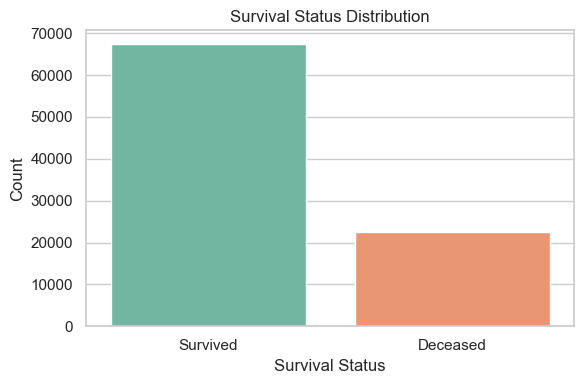

In [9]:
# Set visualization style
sns.set(style="whitegrid")

# Basic class distribution of the target variable
survival_counts = df['Survival_Status'].value_counts()

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survival_Status', hue='Survival_Status', palette='Set2', legend=False)
plt.title("Survival Status Distribution")
plt.ylabel("Count")
plt.xlabel("Survival Status")
plt.tight_layout()
plt.show()

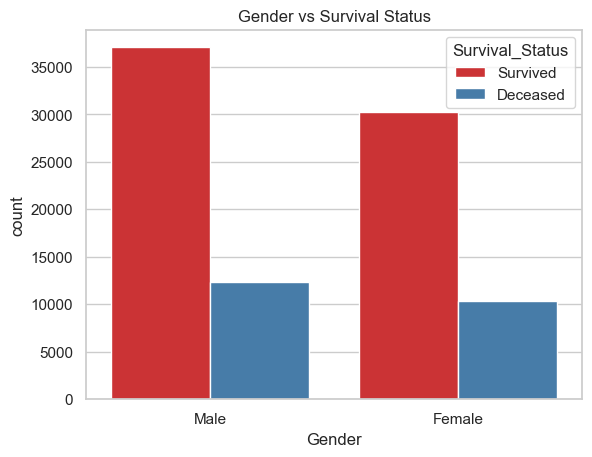

In [10]:
### Gender Distribution
sns.countplot(data=df, x="Gender", hue="Survival_Status", palette="Set1")
plt.title("Gender vs Survival Status")
plt.show()

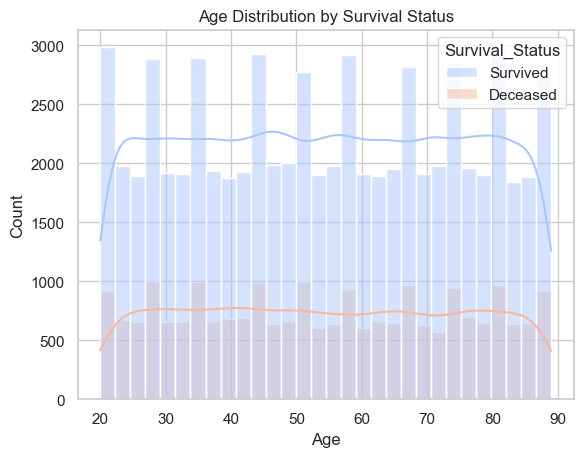

In [11]:
### Age Distribution
sns.histplot(data=df, x="Age", hue="Survival_Status", bins=30, kde=True, palette="coolwarm")
plt.title("Age Distribution by Survival Status")
plt.show()

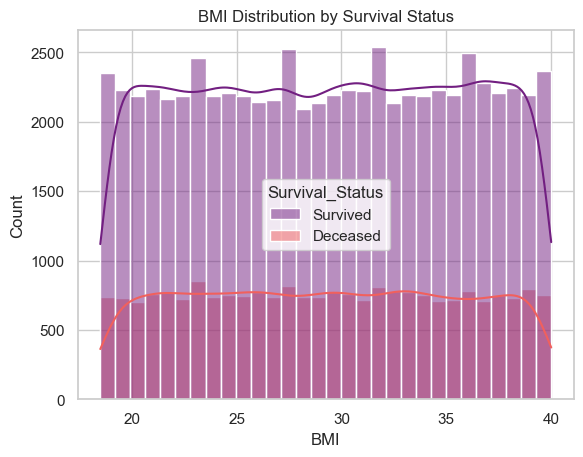

In [12]:
### BMI Distribution
sns.histplot(data=df, x="BMI", hue="Survival_Status", bins=30, kde=True, palette="magma")
plt.title("BMI Distribution by Survival Status")
plt.show()

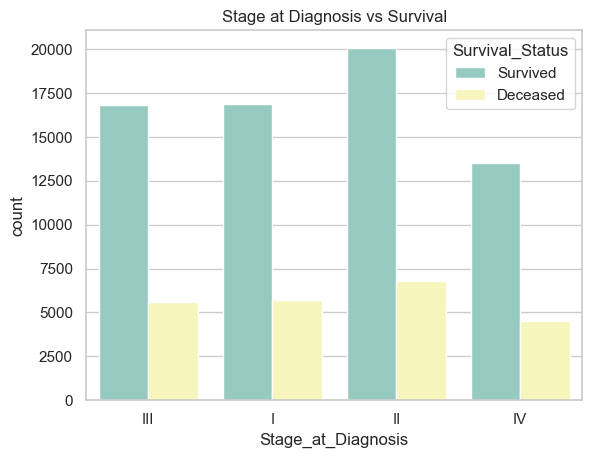

In [13]:
### Stage at Diagnosis
sns.countplot(data=df, x="Stage_at_Diagnosis", hue="Survival_Status", palette="Set3")
plt.title("Stage at Diagnosis vs Survival")
plt.show()

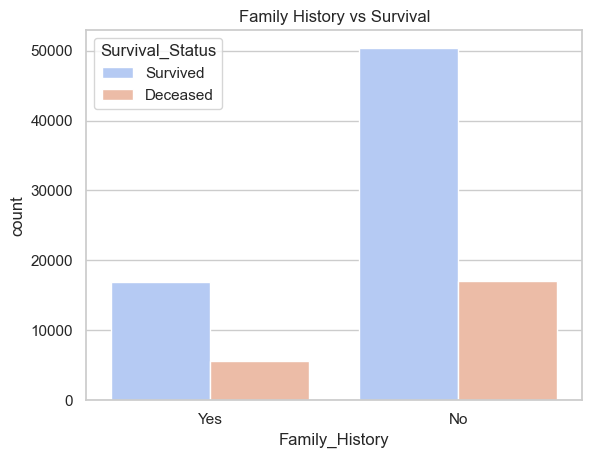

In [14]:
### Family History
sns.countplot(data=df, x="Family_History", hue="Survival_Status", palette="coolwarm")
plt.title("Family History vs Survival")
plt.show()

C:\Users\Jyoti\AppData\Local\Temp\ipykernel_10280\1486335061.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Stage_at_Diagnosis", order=df["Stage_at_Diagnosis"].value_counts().index, palette="coolwarm")


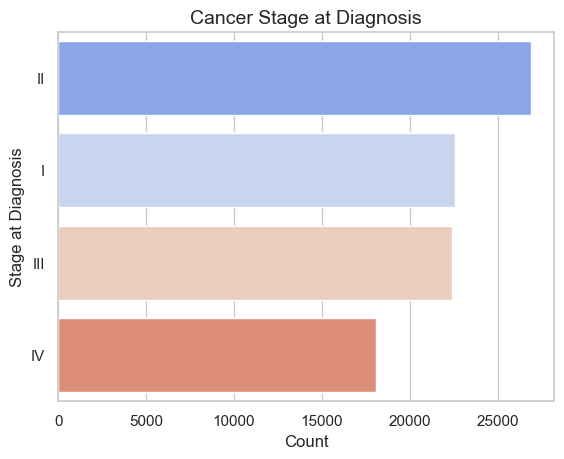

In [15]:
sns.countplot(data=df, y="Stage_at_Diagnosis", order=df["Stage_at_Diagnosis"].value_counts().index, palette="coolwarm")
plt.title("Cancer Stage at Diagnosis", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Stage at Diagnosis")
plt.show()

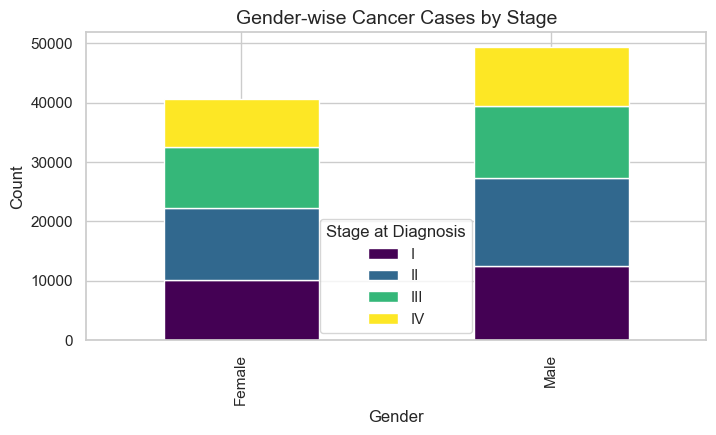

In [16]:
gender_stage = df.groupby(["Gender", "Stage_at_Diagnosis"]).size().unstack()
gender_stage.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="viridis")
plt.title("Gender-wise Cancer Cases by Stage", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Stage at Diagnosis")
plt.show()

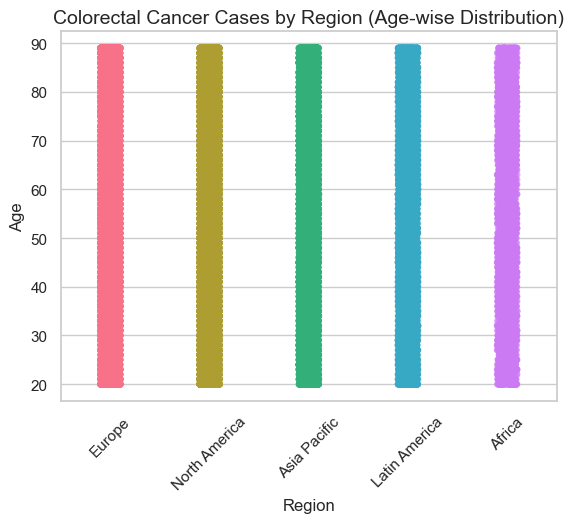

In [17]:
sns.stripplot(
    data=df,
    x="Region",
    y="Age",
    hue="Region",
    jitter=True,
    alpha=0.6,
    palette="husl",
    legend=False
)
plt.title("Colorectal Cancer Cases by Region (Age-wise Distribution)", fontsize=14)
plt.xticks(rotation=45)
plt.ylabel("Age")
plt.show()

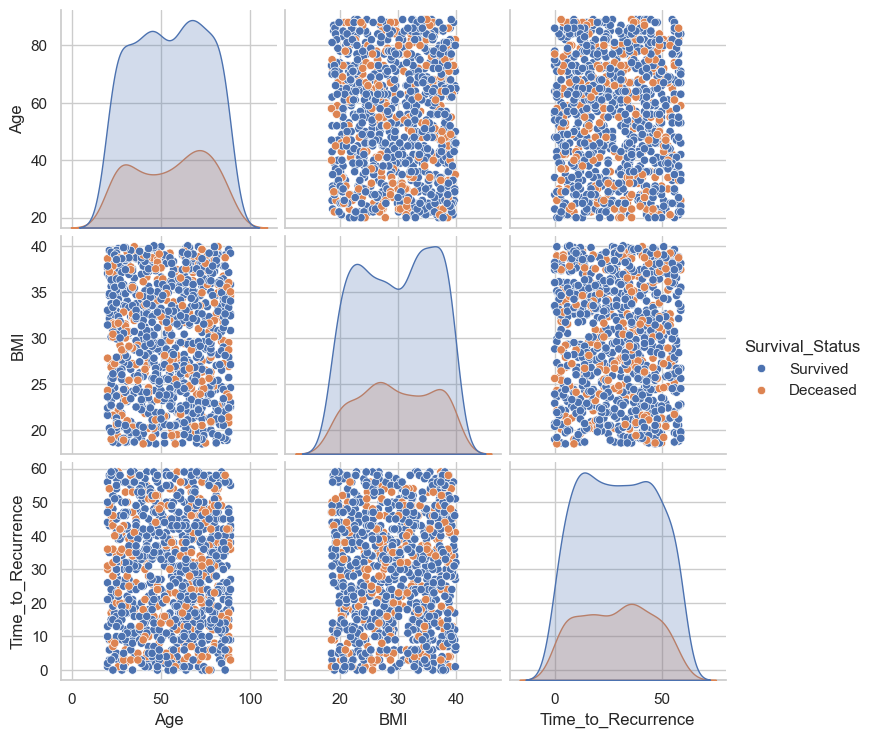

In [18]:
### Pairplot (Optional for Small Samples)
sample = df.sample(1000, random_state=42)
sns.pairplot(sample, hue="Survival_Status", vars=["Age", "BMI", "Time_to_Recurrence"])
plt.show()

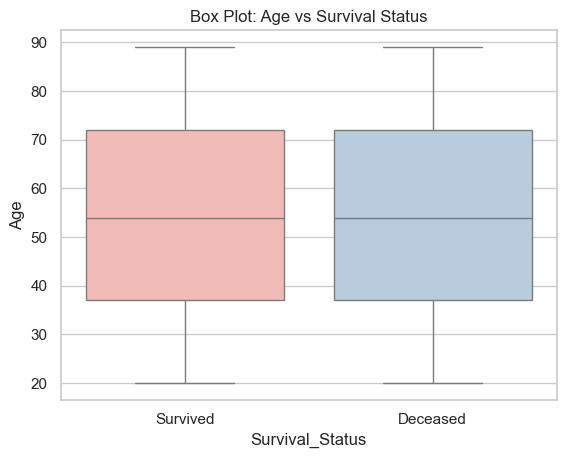

C:\Users\Jyoti\AppData\Local\Temp\ipykernel_10280\2004409182.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Survival_Status", y="BMI", palette="Pastel2")


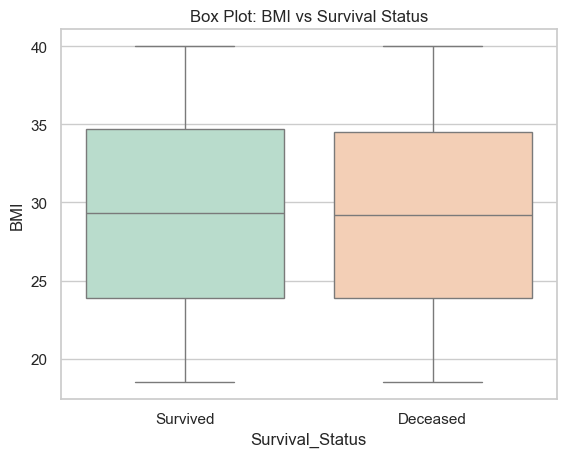

C:\Users\Jyoti\AppData\Local\Temp\ipykernel_10280\2004409182.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Survival_Status", y="Time_to_Recurrence", palette="Set3")


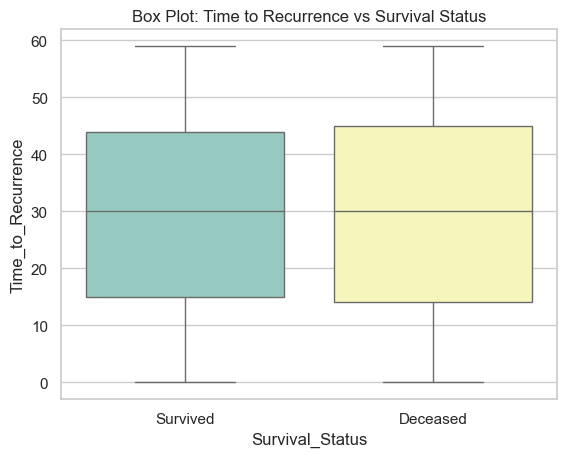

In [19]:
### Box Plot: Age vs Survival Status
sns.boxplot(
    data=df,
    x="Survival_Status",
    y="Age",
    hue="Survival_Status",
    palette="Pastel1",
    legend=False
)
plt.title("Box Plot: Age vs Survival Status")
plt.show()

### Box Plot: BMI vs Survival Status
sns.boxplot(data=df, x="Survival_Status", y="BMI", palette="Pastel2")
plt.title("Box Plot: BMI vs Survival Status")
plt.show()

### Box Plot: Time to Recurrence vs Survival Status
sns.boxplot(data=df, x="Survival_Status", y="Time_to_Recurrence", palette="Set3")
plt.title("Box Plot: Time to Recurrence vs Survival Status")
plt.show()


In [20]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

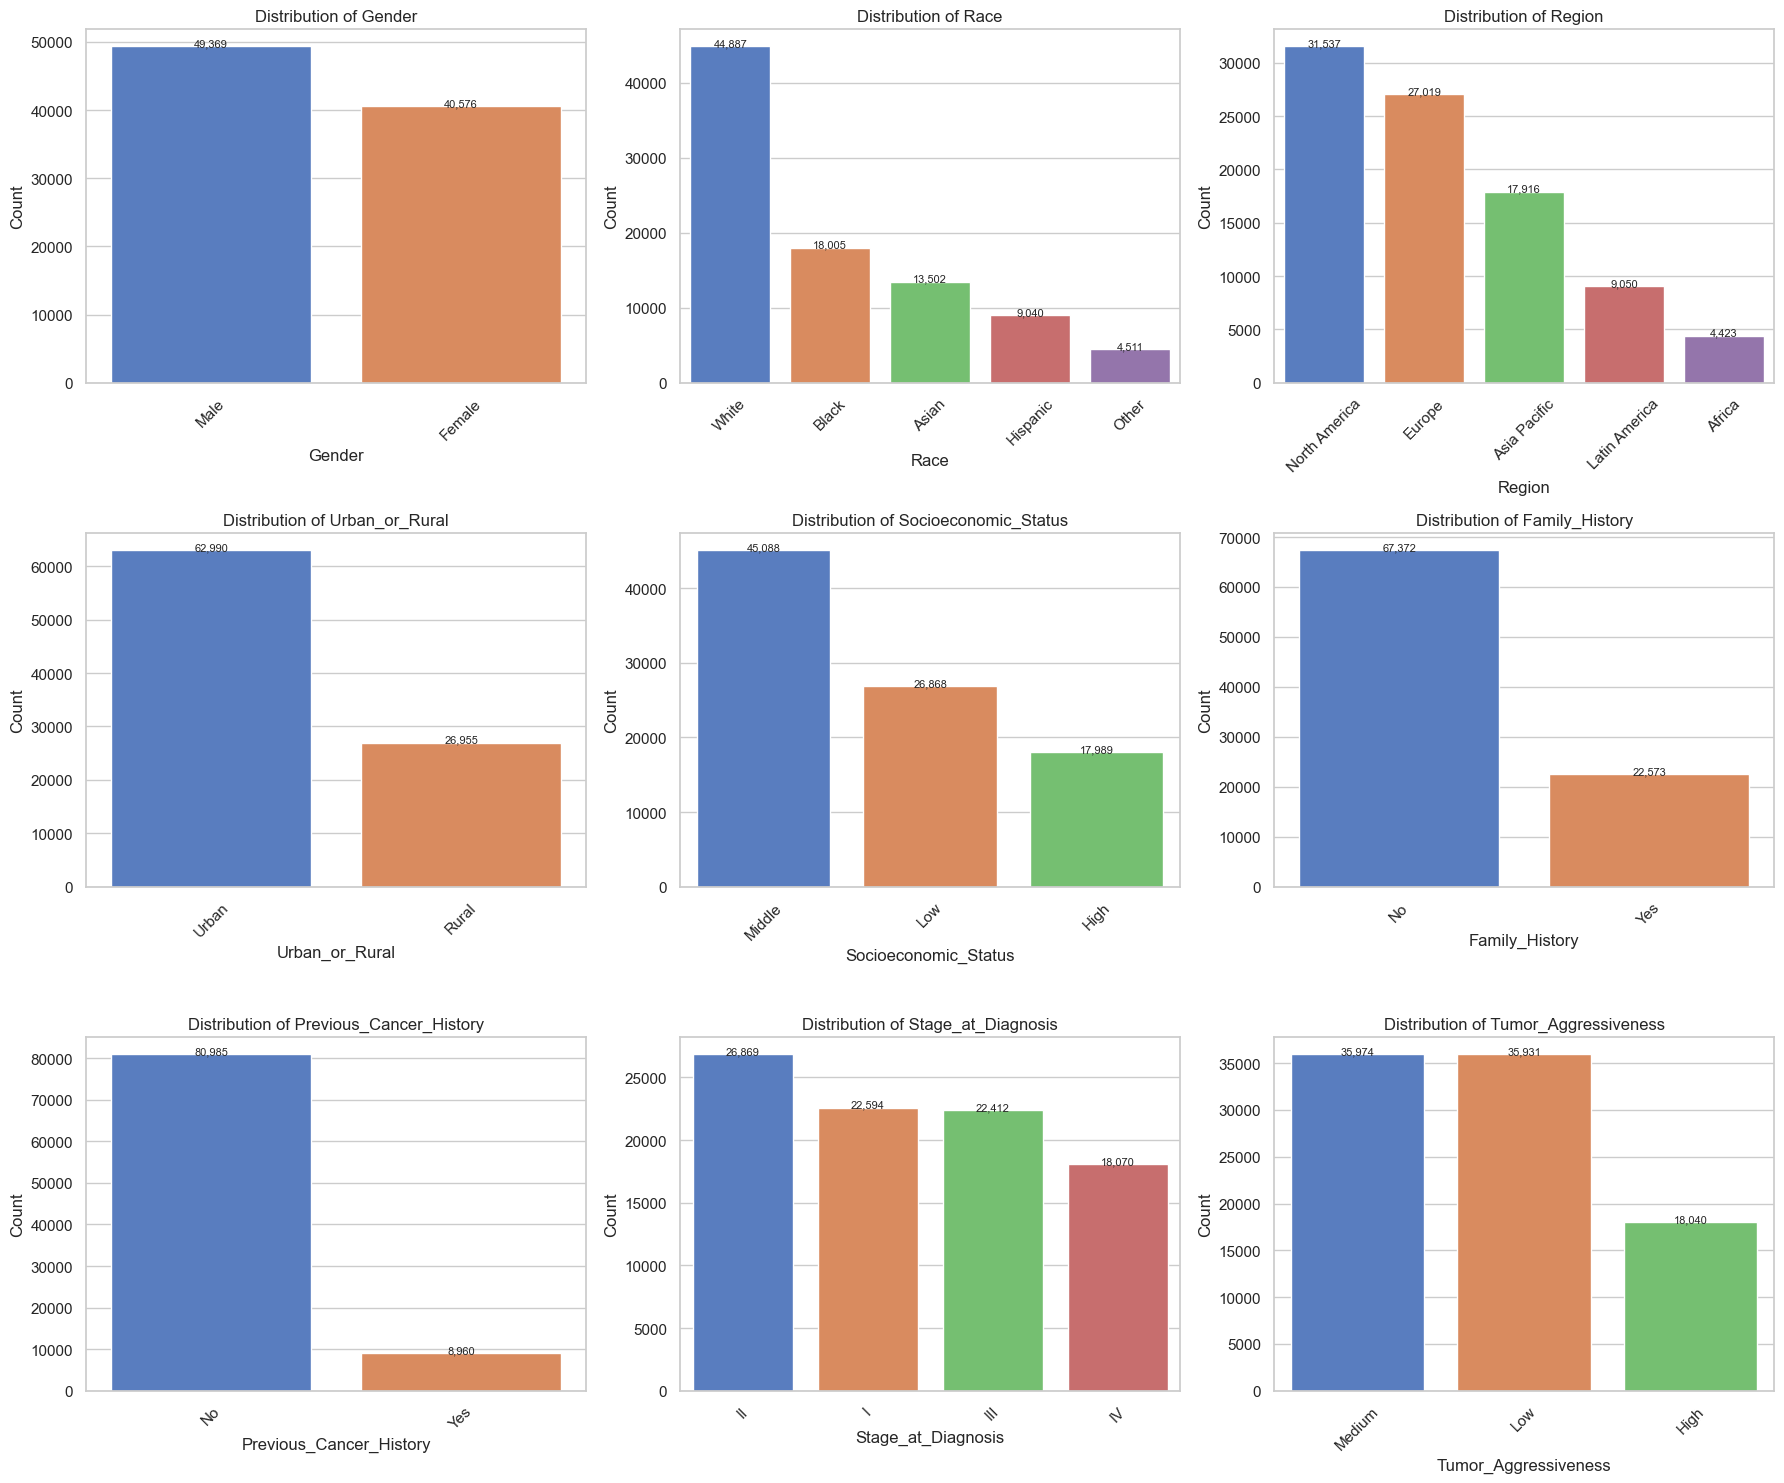

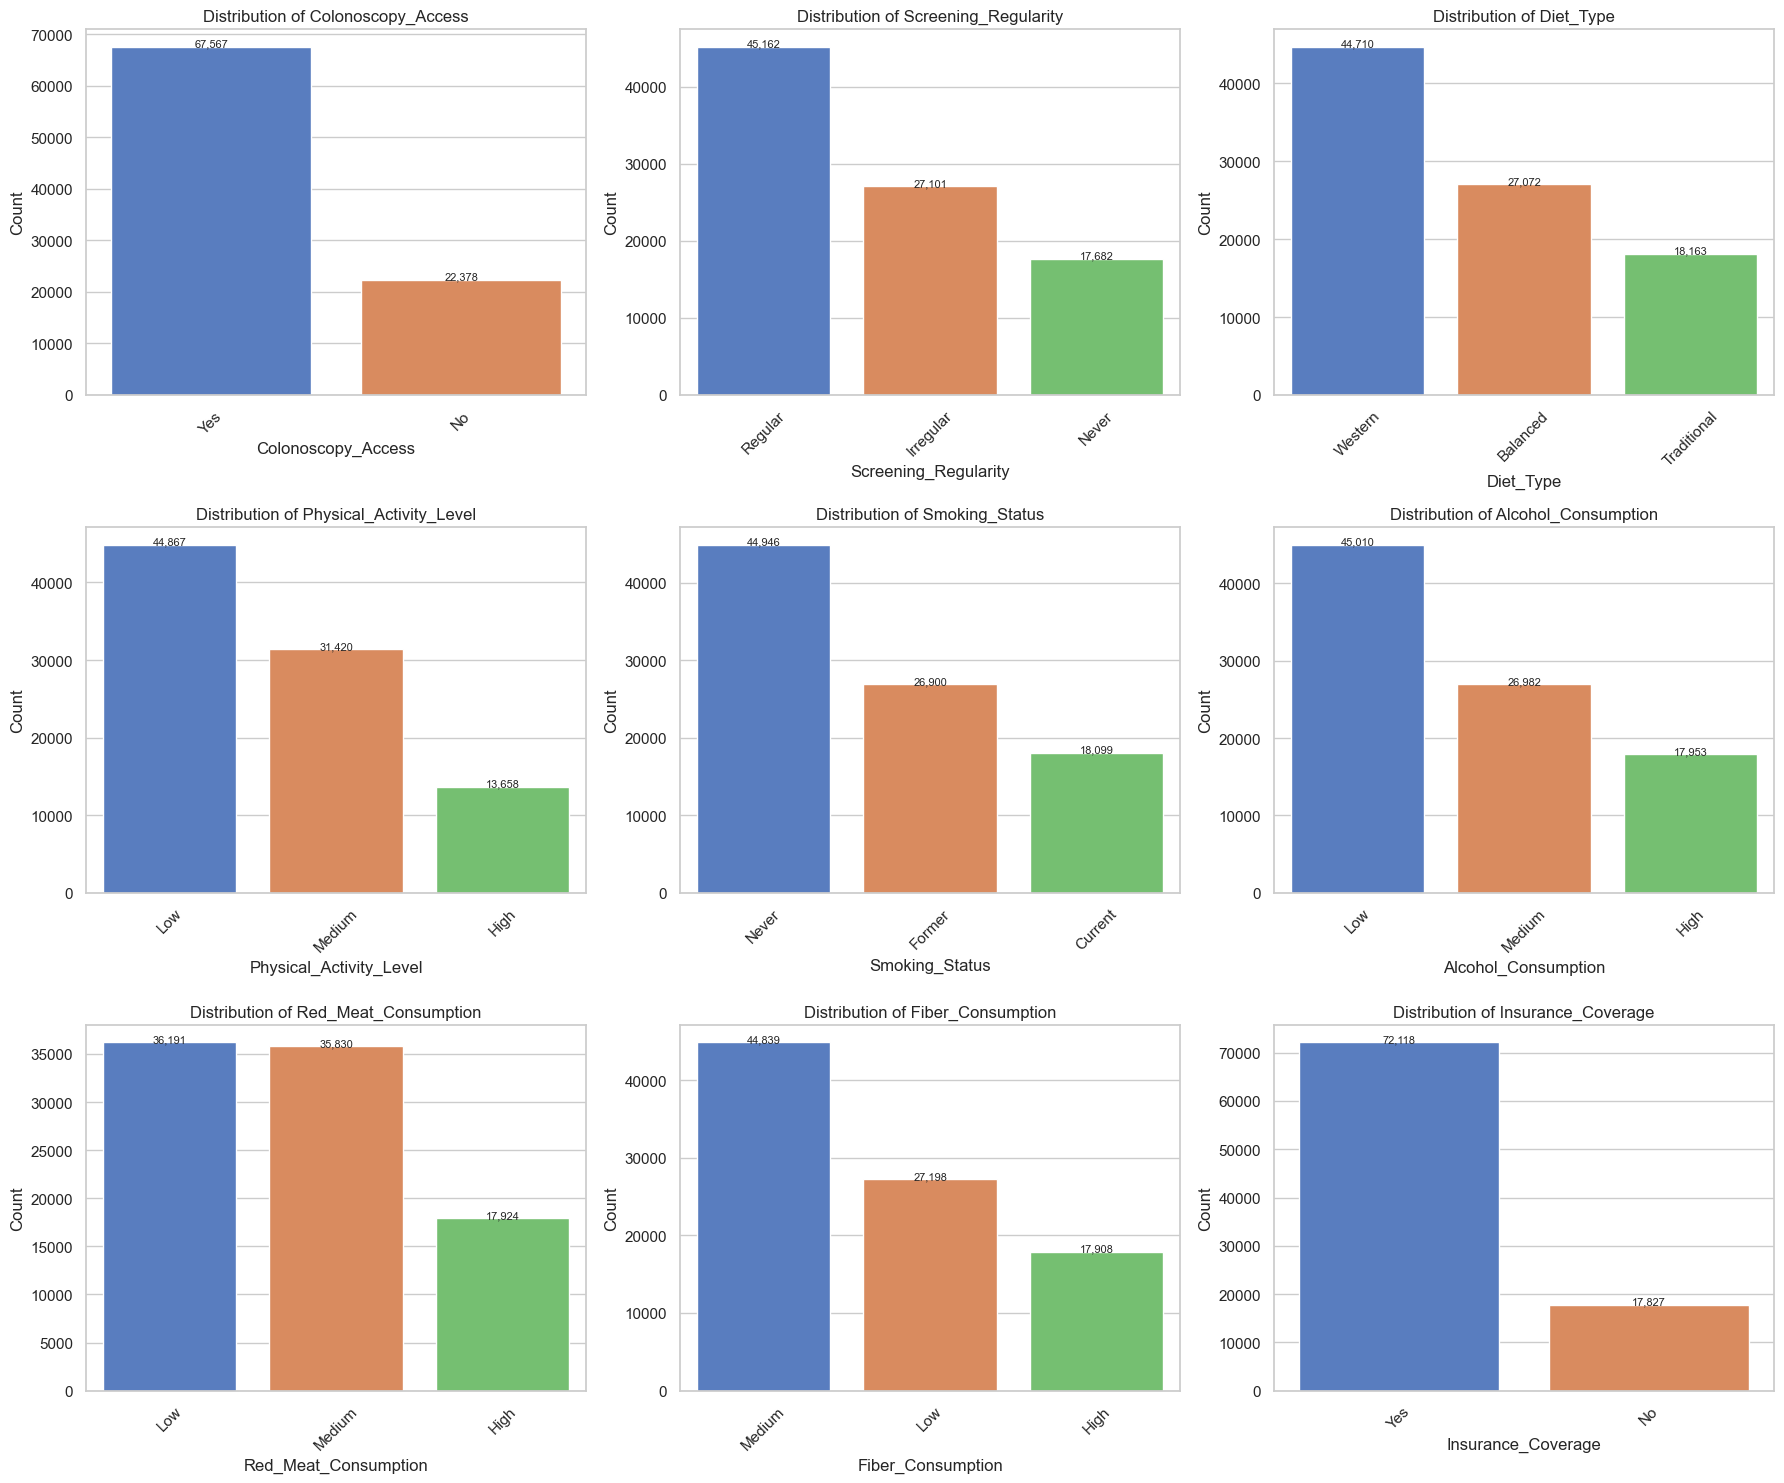

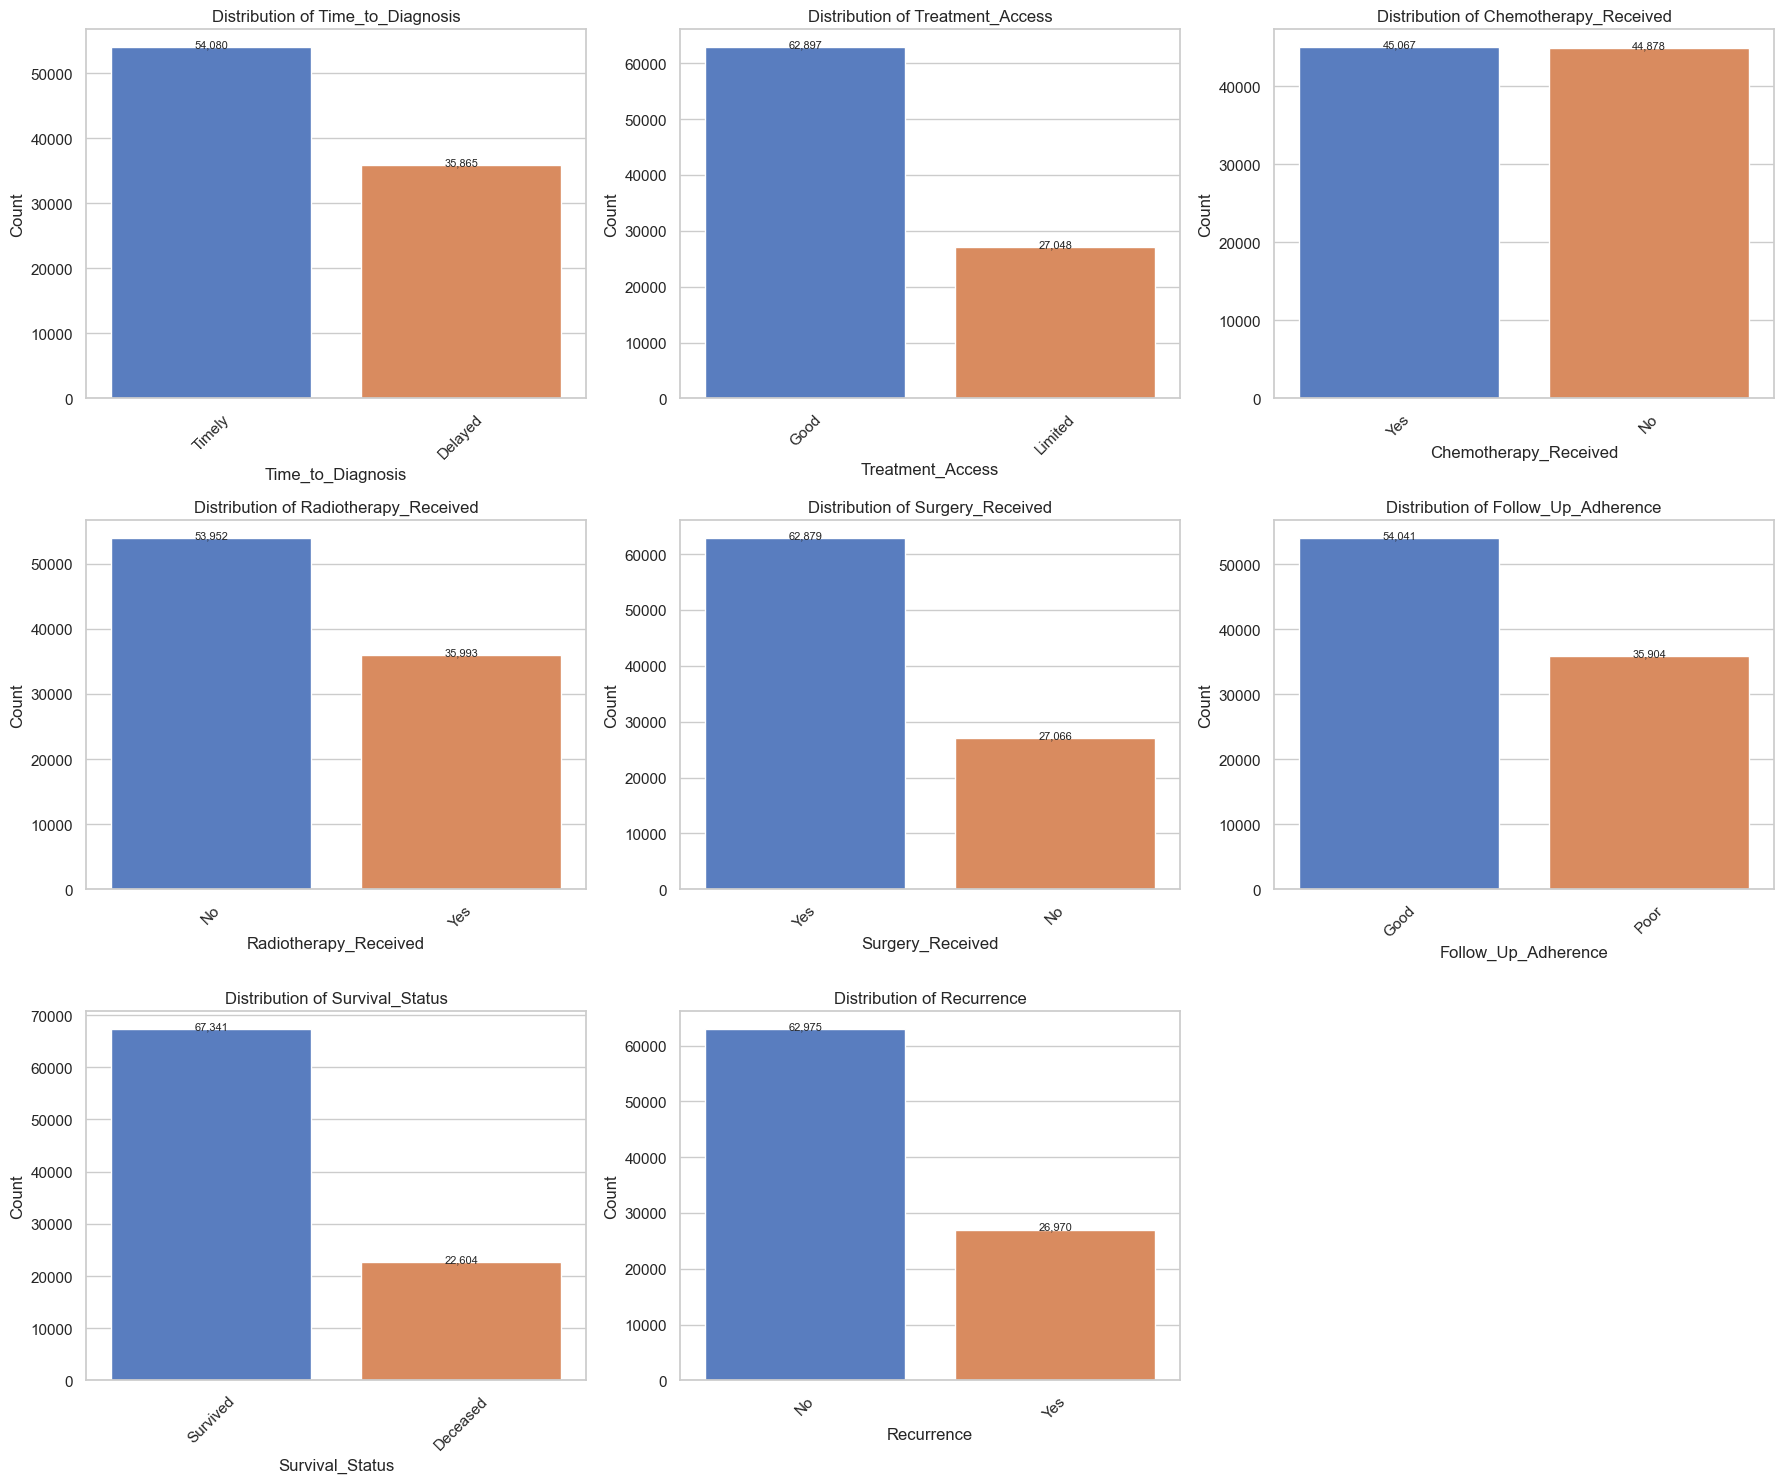

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_categorical_counts(dataframe, columns, figsize=(18, 15)):
    # Safety check
    if len(columns) == 0:
        print("No columns to plot")
        return

    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)

    # Ensure axes is always iterable
    axes = np.array(axes).reshape(-1)

    for i, column in enumerate(columns):
        ax = axes[i]
        value_counts = dataframe[column].value_counts().sort_values(ascending=False)

        sns.barplot(
            x=value_counts.index,
            y=value_counts.values,
            ax=ax,
            hue=value_counts.index,
            palette="muted",
            legend=False
        )

        ax.set_title(f'Distribution of {column}')
        ax.set_xlabel(column)
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

        # Add count labels
        for j, v in enumerate(value_counts.values):
            ax.text(j, v + 0.1, f'{v:,}', ha='center', fontsize=8)

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# -------- MAIN EXECUTION --------

# Get categorical columns
categorical_columns = [col for col in df.columns if df[col].dtype == 'object']

# Remove unwanted column
categorical_columns = [col for col in categorical_columns if col != 'Patient_ID']

# Plot in batches (automatic handling)
batch_size = 9

for i in range(0, len(categorical_columns), batch_size):
    plot_categorical_counts(df, categorical_columns[i:i+batch_size])


In [23]:
# Drop identifier column
df.drop(columns=['Patient_ID'], inplace=True, errors='ignore')

In [24]:
# Encode categorical variables using LabelEncoder
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [25]:
df

,Age,Gender,Race,Region,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,Tumor_Aggressiveness,...,Insurance_Coverage,Time_to_Diagnosis,Treatment_Access,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Follow_Up_Adherence,Survival_Status,Recurrence,Time_to_Recurrence
0,71,1,3,2,1,2,1,0,2,0,...,1,0,0,1,0,0,0,1,0,16
1,34,0,1,4,1,2,0,0,0,2,...,0,1,0,0,1,1,1,0,0,28
2,80,0,4,4,1,2,0,0,2,1,...,1,1,1,0,1,1,0,1,0,26
3,40,1,1,4,0,1,0,0,0,2,...,1,0,1,1,0,1,1,0,0,44
4,43,0,4,2,1,0,1,0,2,1,...,0,0,0,1,0,1,1,0,1,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89940,72,1,4,4,1,2,0,0,3,2,...,1,1,0,0,0,1,1,0,0,25
89941,59,0,0,4,1,1,0,0,1,1,...,1,0,0,0,0,1,0,1,0,46
89942,77,0,4,0,0,0,1,0,0,2,...,1,0,0,0,1,0,0,1,1,41
89943,37,1,3,4,0,0,0,0,1,1,...,1,1,1,0,0,1,0,1,0,47


In [26]:
### Correlation Heatmap (Numerical Features)
#plt.figure(figsize=(16, 12))
#correlation = df.corr()
#sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
#plt.title("Correlation Heatmap")
#plt.show()

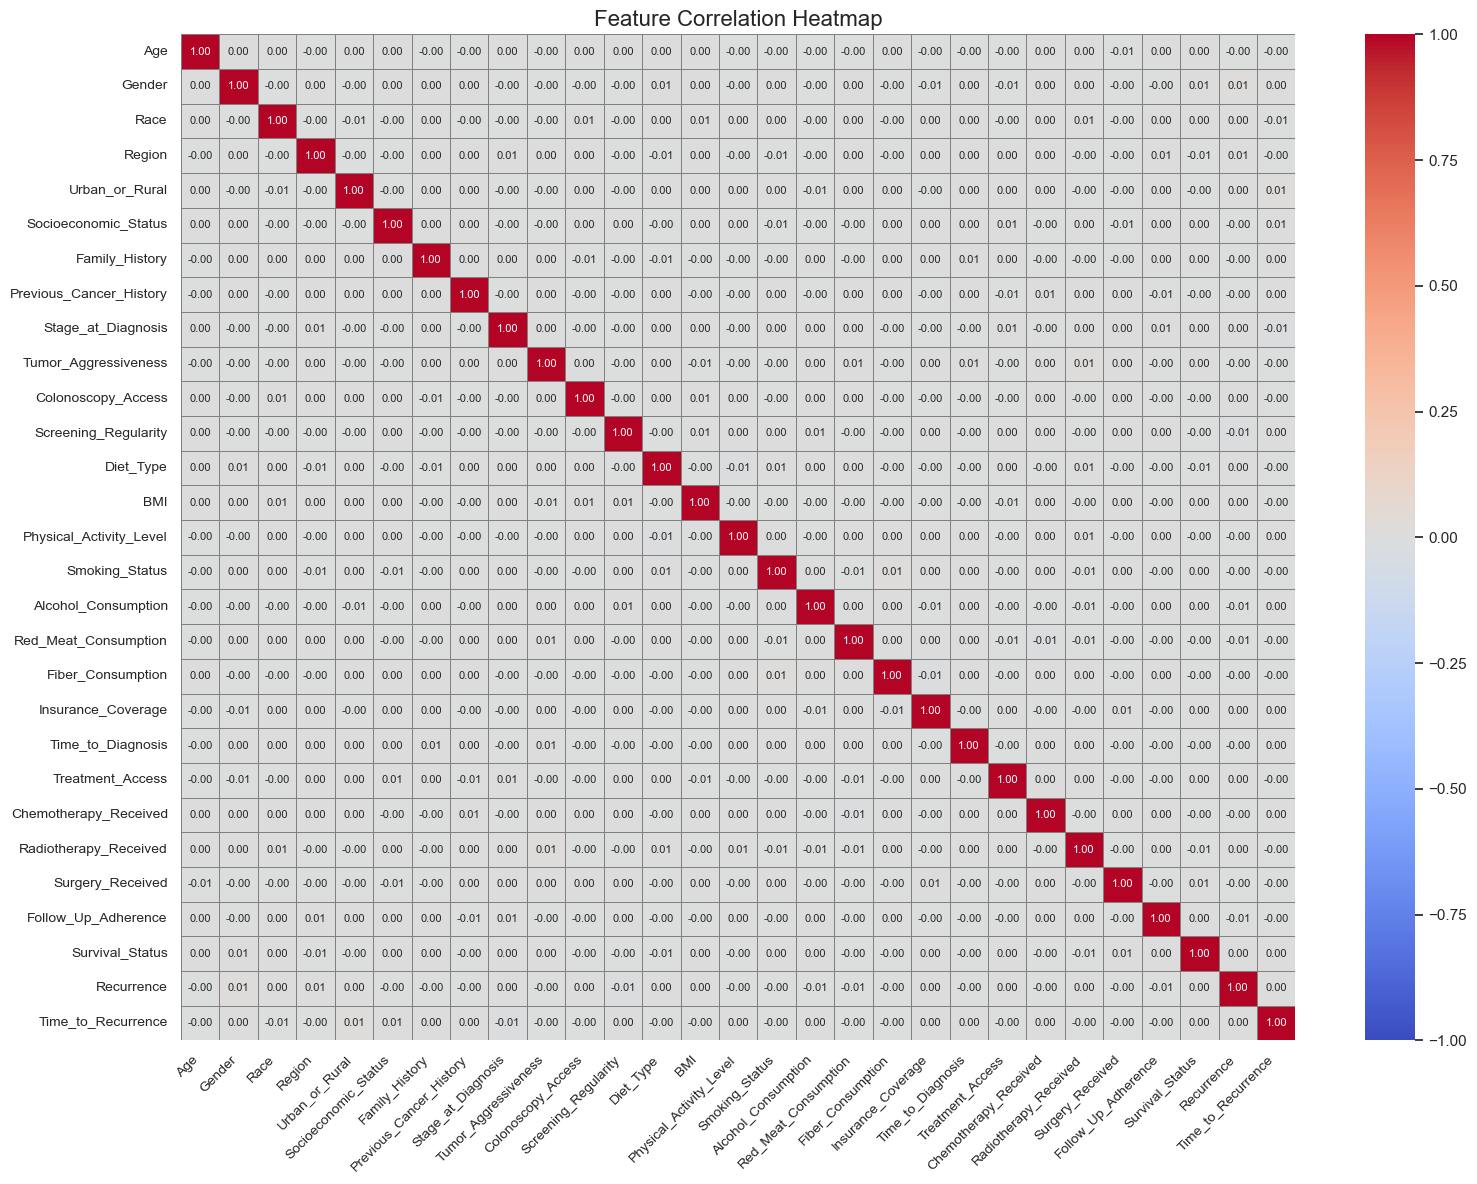

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))  # Wider and taller for better visibility
correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot_kws={"size": 8},  # Smaller font for annotations
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


In [28]:
# Separate features and target
X = df.drop(columns=['Survival_Status'])
y = df['Survival_Status']

In [29]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [31]:
from xgboost import XGBClassifier

results = {}

for name, model in models.items():
    
    if name == "XGBoost":
        model = XGBClassifier(eval_metric='logloss')

    # ✅ Train model
    model.fit(X_train_scaled, y_train)

    # ✅ Then predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [32]:
results_df = pd.DataFrame(results).T.sort_values(by="ROC-AUC", ascending=False)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
XGBoost,0.747401,0.751824,0.990975,0.854991,0.500552
Decision Tree,0.609650,0.751315,0.718302,0.734438,0.499723
K-Nearest Neighbors,0.695703,0.750093,0.892366,0.815068,0.496117
Logistic Regression,0.751459,0.751459,1.000000,0.858095,0.495940
Random Forest,0.751404,0.751445,0.999926,0.858059,0.495123


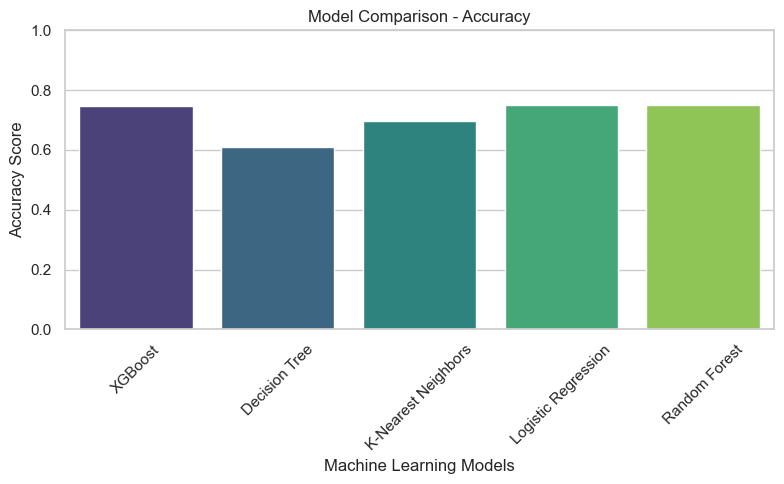

In [34]:
# Plot model accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(x=results_df.index, y=results_df["Accuracy"], palette="viridis")
plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy Score")
plt.xlabel("Machine Learning Models")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
